# Introduction
This project focuses on customer segmentation based on Average Order Value (AOV). By analyzing how much customers typically spend per order, the business can better understand purchasing behavior and design strategies tailored to different customer groups.

## Business Context
In today’s competitive retail environment, companies must balance attracting new customers with maximizing the value of existing ones. Understanding spending patterns is crucial for:

- Designing effective marketing campaigns

- Optimizing product bundles and promotions

- Building loyalty programs that match customer value levels

## Problem Statement
Currently, the business faces challenges in differentiating between low-value customers, who make frequent but small purchases, and high-value customers, who contribute disproportionately to revenue. Without clear segmentation, marketing efforts risk being too generic, leading to missed opportunities for growth and profitability.

## Objective
The objective of this project is to:

- Segment customers into three groups (low, medium, high) based on their AOV.

- Identify the distribution of customers across these segments to highlight where most revenue is generated.

- Provide actionable insights that guide targeted marketing, resource allocation, and customer relationship strategies.

## Import libraries and dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np

In [2]:
df = pd.read_csv('https://huggingface.co/datasets/shouzen/final_data_sale/resolve/main/Final_Data_Sales.csv')
df

,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,...,order_id,user_id,product_id.1,inventory_item_id,status,created_at.1,shipped_at,delivered_at,returned_at,sale_price
0,1,16783,2019-05-23,2019-07-20,28.325000,Tops & Tees,Calvin Klein Sportswear Men's Slim Fit Longsle...,Calvin Klein,55.000000,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,16783,2020-11-08,0000-00-00,28.325000,Tops & Tees,Calvin Klein Sportswear Men's Slim Fit Longsle...,Calvin Klein,55.000000,Men,...,1.0,1.0,16783.0,2.0,Complete,2019-07-20,2019-07-18,2019-07-22,0000-00-00,55.000000
2,3,21357,2019-06-10,2019-07-21,35.095548,Jeans,RVCA Spanky II Denim Pant - Men's,RVCA,68.949997,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,21357,2021-12-22,0000-00-00,35.095548,Jeans,RVCA Spanky II Denim Pant - Men's,RVCA,68.949997,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,21357,2020-04-19,0000-00-00,35.095548,Jeans,RVCA Spanky II Denim Pant - Men's,RVCA,68.949997,Men,...,1.0,1.0,21357.0,5.0,Complete,2019-07-21,2019-07-18,2019-07-22,0000-00-00,68.949997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487389,487390,20796,2020-08-23,0000-00-00,38.144549,Jeans,Cinch White Label Jeans for Men Relaxed Fit Li...,Cinch,69.989998,Men,...,124511.0,100000.0,20796.0,487390.0,Shipped,2022-05-26,2022-05-28,0000-00-00,0000-00-00,69.989998
487390,487391,20039,2021-05-12,2021-06-08,22.096840,Suits & Sport Coats,Port Authority J790 Glacier Soft Shell Jacket,Port Authority,49.880001,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
487391,487392,20039,2021-11-02,0000-00-00,22.096840,Suits & Sport Coats,Port Authority J790 Glacier Soft Shell Jacket,Port Authority,49.880001,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
487392,487393,20039,2020-03-22,0000-00-00,22.096840,Suits & Sport Coats,Port Authority J790 Glacier Soft Shell Jacket,Port Authority,49.880001,Men,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cleaning up data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 487394 entries, 0 to 487393
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              487394 non-null  int64  
 1   product_id                      487394 non-null  int64  
 2   created_at                      487394 non-null  str    
 3   sold_at                         487394 non-null  str    
 4   cost                            487394 non-null  float64
 5   product_category                487394 non-null  str    
 6   product_name                    487359 non-null  str    
 7   product_brand                   487020 non-null  str    
 8   product_retail_price            487394 non-null  float64
 9   product_department              487394 non-null  str    
 10  product_sku                     487394 non-null  str    
 11  product_distribution_center_id  487394 non-null  int64  
 12  id.1                       

In [4]:
df.loc[:, ['id','id.1', 'product_id', 'product_id.1', 'created_at', 'created_at.1', 'order_id', 'product_distribution_center_id']]

,id,id.1,product_id,product_id.1,created_at,created_at.1,order_id,product_distribution_center_id
0,1,NaN,16783,NaN,2019-05-23,NaN,NaN,3
1,2,1.0,16783,16783.0,2020-11-08,2019-07-20,1.0,3
2,3,NaN,21357,NaN,2019-06-10,NaN,NaN,8
3,4,NaN,21357,NaN,2021-12-22,NaN,NaN,8
4,5,2.0,21357,21357.0,2020-04-19,2019-07-21,1.0,8
...,...,...,...,...,...,...,...,...
487389,487390,180507.0,20796,20796.0,2020-08-23,2022-05-26,124511.0,3
487390,487391,NaN,20039,NaN,2021-05-12,NaN,NaN,6
487391,487392,NaN,20039,NaN,2021-11-02,NaN,NaN,6
487392,487393,NaN,20039,NaN,2020-03-22,NaN,NaN,6


In [5]:
df_cleaned = df.rename(columns=
    {'id.1':'line_item_number',
    'created_at.1': 'verified_at'
    }
)
# As the column 'sold at' is equivalent to the column 'verified_at', we will remove it to make it clearer.
df_cleaned = df_cleaned.drop(['product_id.1','sold_at', 'id'], axis = 1)
df_cleaned = df_cleaned[df_cleaned['status'].notna()].reset_index()
df_cleaned


,index,product_id,created_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,...,line_item_number,order_id,user_id,inventory_item_id,status,verified_at,shipped_at,delivered_at,returned_at,sale_price
0,1,16783,2020-11-08,28.325000,Tops & Tees,Calvin Klein Sportswear Men's Slim Fit Longsle...,Calvin Klein,55.000000,Men,7FBF2D8E7B84E90FD9E2698DB2D22362,...,1.0,1.0,1.0,2.0,Complete,2019-07-20,2019-07-18,2019-07-22,0000-00-00,55.000000
1,4,21357,2020-04-19,35.095548,Jeans,RVCA Spanky II Denim Pant - Men's,RVCA,68.949997,Men,BDBE7E66F577B4E312FCC1B94EACC673,...,2.0,1.0,1.0,5.0,Complete,2019-07-21,2019-07-18,2019-07-22,0000-00-00,68.949997
2,8,26458,2020-08-05,5.515400,Underwear,Men's Assorted Plaid Printed 3 Pack Boxer Shorts,Venom,11.990000,Men,F82B2A73A3F905EB4679A24495A79EE3,...,3.0,1.0,1.0,9.0,Complete,2019-07-20,2019-07-18,2019-07-22,0000-00-00,11.990000
3,12,27726,2021-09-20,28.294341,Swim,Coolibar UPF 50+ Men's Short-Sleeve Quarter Zi...,Coolibar,49.990002,Men,98A81153211BC18454FD5747DA413E57,...,4.0,1.0,1.0,13.0,Complete,2019-07-19,2019-07-18,2019-07-22,0000-00-00,49.990002
4,14,27061,2020-07-01,17.430000,Sleep & Lounge,Majestic International Men's Grahams Cotton Lo...,Majestic International,42.000000,Men,3DC91C9313038CE8C97966F7F4194AAC,...,5.0,2.0,1.0,15.0,Processing,2021-11-30,0000-00-00,0000-00-00,0000-00-00,42.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180503,487383,15264,2020-10-23,4.450050,Plus,Wayfarer PL701 Dark Polarized Retro Sunglasses...,Elements of Style,8.990000,Women,CE738ADF821B780CFCDE4100E633E51A,...,180504.0,124508.0,99997.0,487384.0,Returned,2020-07-02,2020-07-03,2020-07-07,2020-07-09,8.990000
180504,487385,5583,2020-01-29,24.200000,Pants & Capris,Flying Tomato Bohemian Pants,Flying Tomato,44.000000,Women,43C656628A4A479E108ED86F7A28A010,...,180505.0,124509.0,99998.0,487386.0,Processing,2022-02-01,0000-00-00,0000-00-00,0000-00-00,44.000000
180505,487387,17518,2020-10-07,42.975000,Fashion Hoodies & Sweatshirts,Dc Men's Blackheart Zh Hoodie,DC,75.000000,Men,73C2BF297C5AEC4BCBDEB4435328C335,...,180506.0,124510.0,99999.0,487388.0,Shipped,2022-05-10,2022-05-11,0000-00-00,0000-00-00,75.000000
180506,487389,20796,2020-08-23,38.144549,Jeans,Cinch White Label Jeans for Men Relaxed Fit Li...,Cinch,69.989998,Men,2B20B3682E832DF224A5C404D8F9F365,...,180507.0,124511.0,100000.0,487390.0,Shipped,2022-05-26,2022-05-28,0000-00-00,0000-00-00,69.989998


In [6]:
# Create a list of date columns that need to be converted to the appropriate data type.
date_cols = ['created_at', 'verified_at', 'shipped_at', 'delivered_at', 'returned_at']

# convert all date-related columns into datetime format
df_cleaned[date_cols] = df_cleaned[date_cols].apply(pd.to_datetime, errors='coerce')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21396\317201317.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned[date_cols] = df_cleaned[date_cols].apply(pd.to_datetime, errors='coerce')


In [7]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 180508 entries, 0 to 180507
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   index                           180508 non-null  int64         
 1   product_id                      180508 non-null  int64         
 2   created_at                      180508 non-null  datetime64[us]
 3   cost                            180508 non-null  float64       
 4   product_category                180508 non-null  str           
 5   product_name                    180496 non-null  str           
 6   product_brand                   180365 non-null  str           
 7   product_retail_price            180508 non-null  float64       
 8   product_department              180508 non-null  str           
 9   product_sku                     180508 non-null  str           
 10  product_distribution_center_id  180508 non-null  int64         
 11

In [8]:
df_cleaned['status'].value_counts()

status
Shipped       54467
Complete      45283
Processing    36225
Cancelled     26781
Returned      17752
Name: count, dtype: int64

## Question 1: Which time has the most revenue?
Net Revenue: doanh thu thuần sau khi trừ đi chi phí giảm giá,chiết khấu và hàng trả lại
Gross Profict: lợi nhuận gộp sau khi trừ đi giá vốn hàng bán

In [9]:
# Create a new column called 'sale_month' contains the information of selling time converted to 'month' form.
df_cleaned['sale_month'] = df_cleaned['verified_at'].dt.month

# Create a new column names 'gross_profit', which is made by 'sale_price' - 'cost'
df_cleaned['gross_profit'] = df_cleaned['sale_price'] - df_cleaned['cost']

# Remove the Cancelled and Returned products from the revenue
remove = ['Cancelled', 'Returned']
df_cleaned_1a = df_cleaned[~df_cleaned['status'].isin(remove)].groupby('sale_month')['sale_price'].sum().reset_index()
df_cleaned_1a



,sale_month,sale_price
0,1,6.858193e+05
1,2,6.862669e+05
2,3,8.540704e+05
3,4,9.493030e+05
4,5,1.366789e+06
5,6,5.358804e+05
6,7,4.018895e+05
7,8,4.560394e+05
8,9,4.585255e+05
9,10,5.440019e+05


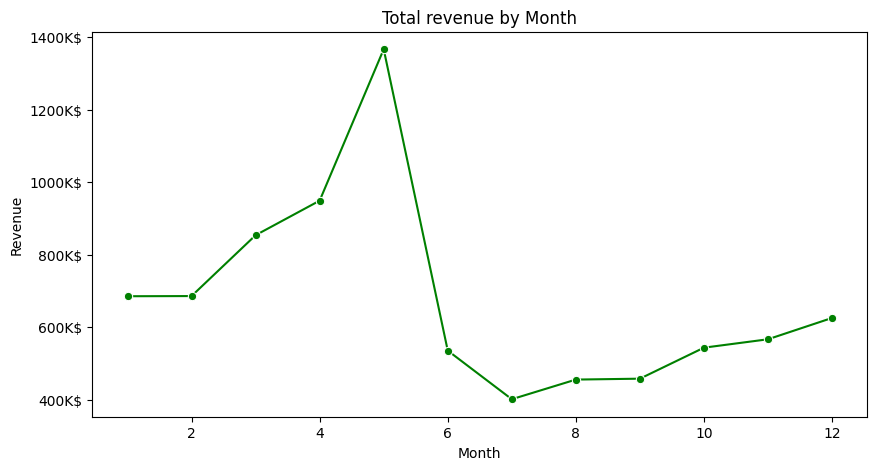

In [10]:
# Create a lineplot illustrating the trend of revenue
import matplotlib.ticker as mticker

plt.figure(figsize = (10,5))
sns.lineplot(data = df_cleaned_1a, x = 'sale_month', y = 'sale_price', marker = 'o', color = 'green')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.title('Total revenue by Month')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K$"))
plt.show()


The chart shows a clear seasonal trend: revenue rises steadily from January, peaks sharply in May, then drops significantly in June before gradually recovering toward the end of the year. This pattern highlights a strong mid‑year spike followed by a downturn and stabilization. The company should investigate the drivers of May’s success (marketing, product launches, holidays) and replicate them. Prepare for June’s downturn by adjusting inventory, staffing, and cash flow planning.

In [11]:
remove = ['Cancelled', 'Returned']
df_cleaned_1b = df_cleaned[~df_cleaned['status'].isin(remove)].groupby('sale_month')['gross_profit'].sum().reset_index()
df_cleaned_1b

,sale_month,gross_profit
0,1,356142.746127
1,2,356342.438352
2,3,442636.696018
3,4,493656.121051
4,5,709922.521150
5,6,278294.078375
6,7,208144.935405
7,8,235925.694909
8,9,237726.845042
9,10,282779.706715


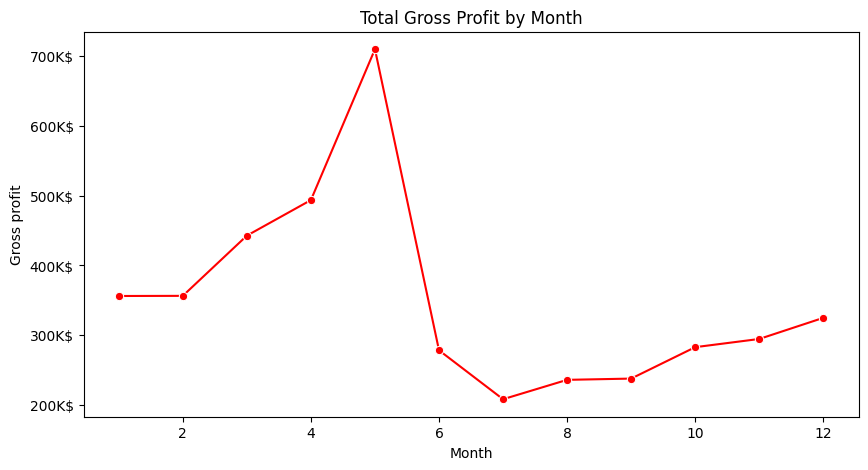

In [12]:
plt.figure(figsize = (10,5))
sns.lineplot(data = df_cleaned_1b, x = 'sale_month', y = 'gross_profit', marker = 'o', color = 'red')
plt.ylabel('Gross profit')
plt.xlabel('Month')
plt.title('Total Gross Profit by Month')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K$"))
plt.show()

Gross profit rises steadily until May, then peaks sharply in June. After June, there’s a steep decline in July, followed by a slow recovery toward year‑end. The pattern is similar to revenue but with a more pronounced spike and drop, suggesting cost dynamics also play a role.

June’s exceptional profit: The company should investigate what drove the unusually high gross profit — possibly lower costs, special pricing, or a one‑time event. Replicating those conditions could be valuable. July’s sharp decline: This signals a risk point. It may be due to higher costs, reduced demand, or operational inefficiencies.

## Question 2: Which factors affect the status?
Do retunred orders have the longer delivery time than others?

Which distribution centers have the fastest vs. slowest delivery times?


In [13]:
df_cleaned['delivery_time'] = df_cleaned['delivered_at'] - df_cleaned['shipped_at']

In [14]:
df_cleaned_2a = (
    df_cleaned[['status', 'delivery_time']]
    .dropna(subset = 'delivery_time')
    .groupby('status')
    .median()
    .reset_index()
)
df_cleaned_2a

,status,delivery_time
0,Complete,3 days
1,Returned,3 days


This means the delivery time of completed orders and returned orders is likely equal. We go on investigating further to discover if there is a relation betwween the delivery time of two kinds of status by percentage.

In [15]:
df_cleaned_2b = df_cleaned['delivery_time'].value_counts().reset_index().sort_values(by = 'count', ascending = False)
df_cleaned_2b

,delivery_time,count
0,3 days,12852
1,1 days,12698
2,4 days,12439
3,2 days,12394
4,5 days,6336
5,0 days,6316


In [16]:
df_cleaned_2c = (
    df_cleaned[df_cleaned['status'] == 'Returned']['delivery_time']
    .value_counts()
    .reset_index()
    .sort_values(by = 'count', ascending = False)
    )
df_cleaned_2c


,delivery_time,count
0,3 days,3612
1,1 days,3544
2,4 days,3497
3,2 days,3490
4,0 days,1811
5,5 days,1798


In [17]:
df_cleaned_2 = df_cleaned_2b.merge(
    df_cleaned_2c,
    on='delivery_time',
    how='left',
    suffixes=('_total', '_returned')
)

df_cleaned_2 = df_cleaned_2.fillna(0)
df_cleaned_2

,delivery_time,count_total,count_returned
0,3 days,12852,3612
1,1 days,12698,3544
2,4 days,12439,3497
3,2 days,12394,3490
4,5 days,6336,1798
5,0 days,6316,1811


In [18]:
df_cleaned_2['non_returned'] = df_cleaned_2['count_total'] - df_cleaned_2['count_returned']

df_cleaned_2['returned_pct'] = df_cleaned_2['count_returned'] / df_cleaned_2['count_total']
df_cleaned_2['non_returned_pct'] = df_cleaned_2['non_returned'] / df_cleaned_2['count_total']

df_cleaned_2.sort_values(by = 'delivery_time', ascending = True, inplace = True)
df_cleaned_2

,delivery_time,count_total,count_returned,non_returned,returned_pct,non_returned_pct
5,0 days,6316,1811,4505,0.286732,0.713268
1,1 days,12698,3544,9154,0.279099,0.720901
3,2 days,12394,3490,8904,0.281588,0.718412
0,3 days,12852,3612,9240,0.281046,0.718954
2,4 days,12439,3497,8942,0.281132,0.718868
4,5 days,6336,1798,4538,0.283775,0.716225


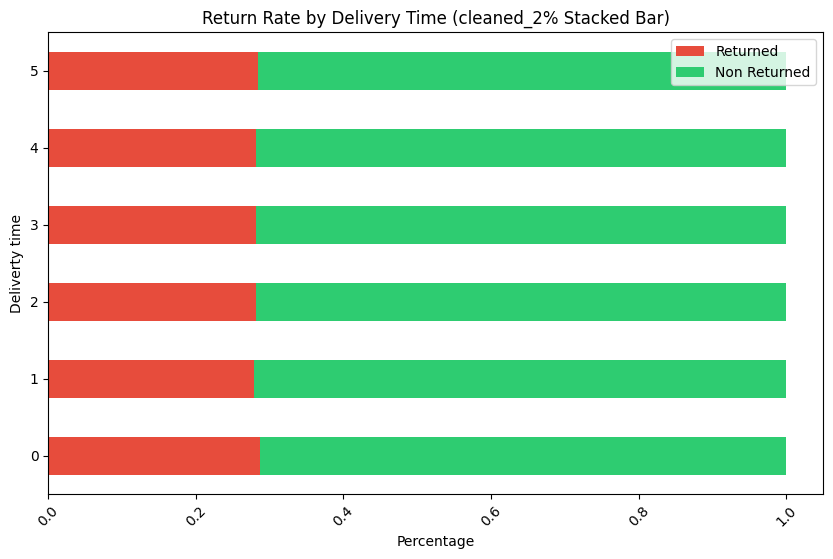

In [19]:
df_cleaned_2['delivery_time_days'] = df_cleaned_2['delivery_time'].dt.days
df_plot = df_cleaned_2.set_index('delivery_time_days')[
    ['returned_pct', 'non_returned_pct']
]

df_plot.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
     color=['#E74C3C', '#2ECC71']
)

plt.title('Return Rate by Delivery Time (cleaned_2% Stacked Bar)')
plt.ylabel('Deliverty time')
plt.xlabel('Percentage')
plt.legend(['Returned', 'Non Returned'])
plt.xticks(rotation=45)

plt.show()

The return rate is almost identical across all delivery time categories, hovering around the same percentage.

Faster delivery (0–1 days) does not show a lower return rate compared to slower delivery (3–5 days).

This consistency suggests that delivery speed is not the main driver of returns.

The company should not expect improvements in delivery time alone to reduce returns. Instead, the focus should shift to other factors such as product quality, accuracy of descriptions, and customer expectations. Delivery performance remains important for satisfaction, but it does not appear to influence the likelihood of returns.

In [20]:
df_cleaned_2d = (
    df_cleaned.groupby('product_distribution_center_id')
    .agg({
        'delivery_time': 'median',
        'product_id': 'count'
    })
    .reset_index()
    )
df_cleaned_2d

,product_distribution_center_id,delivery_time,product_id
0,1,3 days,24056
1,2,2 days,23846
2,3,3 days,22801
3,4,3 days,17355
4,5,2 days,12909
5,6,2 days,16343
6,7,3 days,16681
7,8,3 days,18364
8,9,3 days,16289
9,10,2 days,11864


## Question 3: Customers prefers to which brand?

In [22]:
df_cleaned_3a = (
    df_cleaned.groupby('product_brand')
    .agg(
        quantity=('product_brand', 'count'),
        revenue=('sale_price', 'sum')
    )
    .reset_index()
)
df_cleaned_3a

,product_brand,quantity,revenue
0,!it Jeans,74,3796.199989
1,'47 Brand,9,621.000000
2,007Lingerie,21,285.059999
3,10 Deep,15,1559.249954
4,106Shades,40,334.119989
...,...,...,...
2749,tasc Performance,24,649.000000
2750,turkishtowels,3,449.970016
2751,under.me,6,144.000000
2752,vip boutique,10,159.899998


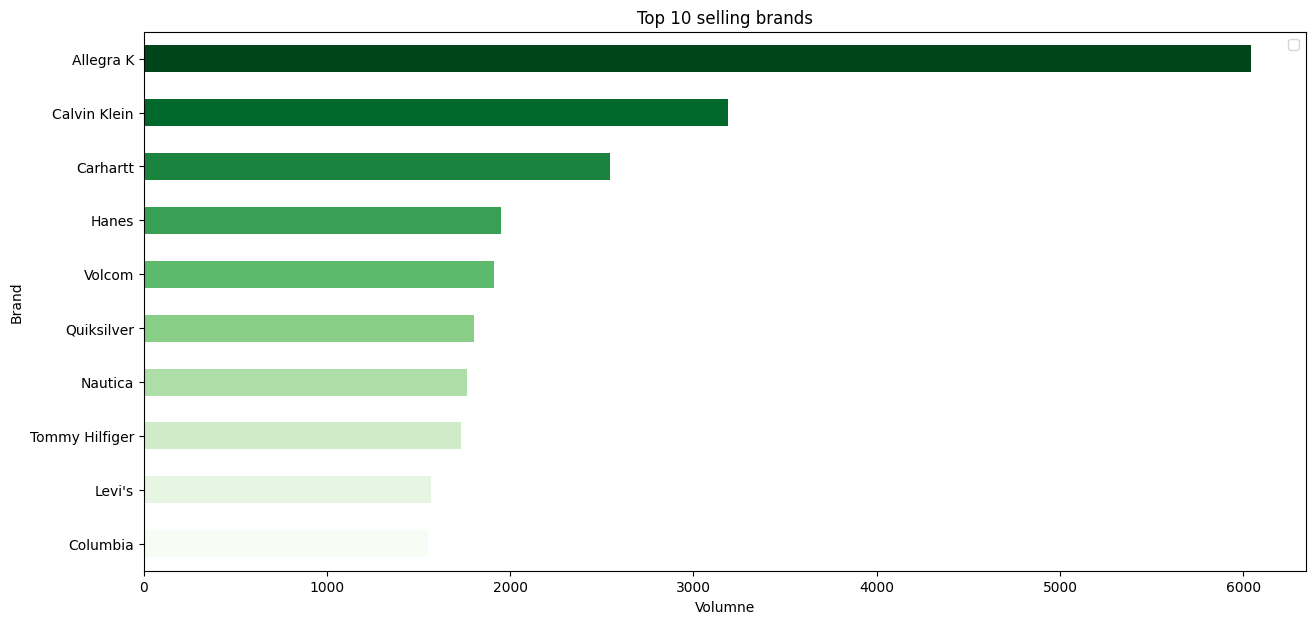

In [23]:
df_cleaned_3a1 = df_cleaned_3a.sort_values(by = 'quantity', ascending  = False).head(10)

norm = np.linspace(0, 1, len(df_cleaned_3a1))
colors = plt.cm.Greens(norm)

df_cleaned_3a1.iloc[::-1].plot(kind = 'barh', y = 'quantity', x = 'product_brand', color = colors, figsize = (15,7))
plt.title('Top 10 selling brands')
plt.legend('')
plt.xlabel('Volumne')
plt.ylabel('Brand')
plt.show()

Allegra K stands out as the dominant brand, with a significantly higher sales count than the others. The next tier includes Calvin Klein, Carhartt, Hanes, and Volcom, which have moderate but still strong sales. Brands like Quiksilver, Nautica, Tommy Hilfiger, Levi’s, and Columbia trail behind, with Columbia showing the lowest count among the top ten.

The company’s sales are highly concentrated in Allegra K, suggesting strong customer preference or effective distribution for this brand. In short: Allegra K is the clear growth driver, while other brands need strategic support to close the gap.

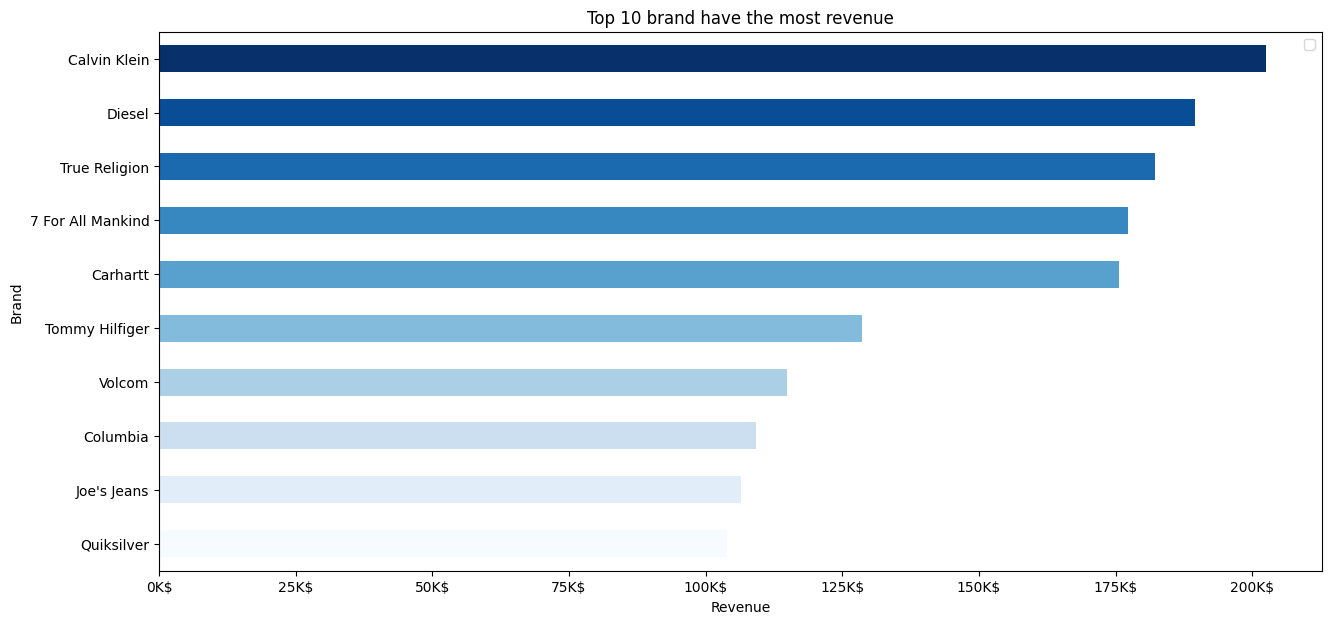

In [24]:
df_cleaned_3a2 = df_cleaned_3a.sort_values(by = 'revenue', ascending  = False).head(10)

norm = np.linspace(0, 1, len(df_cleaned_3a2))
colors = plt.cm.Blues(norm)  

df_cleaned_3a2.iloc[::-1].plot(kind = 'barh', y = 'revenue', x = 'product_brand', color = colors, figsize = (15,7))
plt.title('Top 10 brand have the most revenue')
plt.xlabel('Revenue')
plt.ylabel('Brand')
plt.legend('')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K$'))
plt.show()

Calvin Klein is the clear leader, with revenue far ahead of the rest. Diesel, True Religion, and 7 For All Mankind form the next strong group, showing solid performance but still trailing Calvin Klein. Carhartt, Tommy Hilfiger, and Volcom sit in the mid‑tier, contributing meaningfully but not dominating. Columbia, Joe’s Jeans, and Quiksilver are at the bottom of the top 10, with noticeably lower revenue.

In short: Calvin Klein dominates revenue, premium brands perform strongly, and weaker brands need strategic support to balance the portfolio.

Here’s how we can frame the Weighted Sum method analysis in English for identifying the “optimal brands” that are both high‑selling and high‑revenue

In [26]:
# Normalize the values

df_cleaned_3b = df_cleaned_3a.copy()

quantity_min = df_cleaned_3b['quantity'].min()
quantity_max = df_cleaned_3b['quantity'].max()
df_cleaned_3b['normalized_quantity'] = (df_cleaned_3b['quantity'] - quantity_min)/(quantity_max - quantity_min)

revenue_min = df_cleaned_3b['revenue'].min()
revevue_max = df_cleaned_3b['revenue'].max()
df_cleaned_3b['normalized_revenue'] = (df_cleaned_3b['revenue'] - revenue_min)/(revevue_max - revenue_min)

# Since both criteria are assumed to be equally important, each is given a weight of 0.5.

df_cleaned_3b['brand_score'] = 0.5*df_cleaned_3b['normalized_quantity'] + 0.5*df_cleaned_3b['normalized_revenue']

df_cleaned_3b


,product_brand,quantity,revenue,normalized_quantity,normalized_revenue,brand_score
0,!it Jeans,74,3796.199989,0.012086,0.018739,0.015412
1,'47 Brand,9,621.000000,0.001325,0.003065,0.002195
2,007Lingerie,21,285.059999,0.003311,0.001407,0.002359
3,10 Deep,15,1559.249954,0.002318,0.007696,0.005007
4,106Shades,40,334.119989,0.006457,0.001649,0.004053
...,...,...,...,...,...,...
2749,tasc Performance,24,649.000000,0.003808,0.003203,0.003506
2750,turkishtowels,3,449.970016,0.000331,0.002221,0.001276
2751,under.me,6,144.000000,0.000828,0.000710,0.000769
2752,vip boutique,10,159.899998,0.001490,0.000789,0.001139


In [27]:
top10_optimal_brand = df_cleaned_3b.sort_values(by = 'brand_score', ascending = False).head(10)
top10_optimal_brand

,product_brand,quantity,revenue,normalized_quantity,normalized_revenue,brand_score
447,Calvin Klein,3190,202579.860409,0.527980,1.000000,0.763990
96,Allegra K,6041,86589.299980,1.000000,0.427433,0.713716
465,Carhartt,2547,175679.668898,0.421523,0.867212,0.644368
701,Diesel,1456,189536.809834,0.240894,0.935615,0.588255
29,7 For All Mankind,1118,177234.480442,0.184934,0.874887,0.529910
2488,True Religion,910,182205.499500,0.150497,0.899425,0.524961
2445,Tommy Hilfiger,1730,128631.170167,0.286258,0.634965,0.460612
2585,Volcom,1912,114809.609672,0.316391,0.566737,0.441564
1942,Quiksilver,1804,103904.110069,0.298510,0.512904,0.405707
567,Columbia,1549,109231.269619,0.256291,0.539201,0.397746


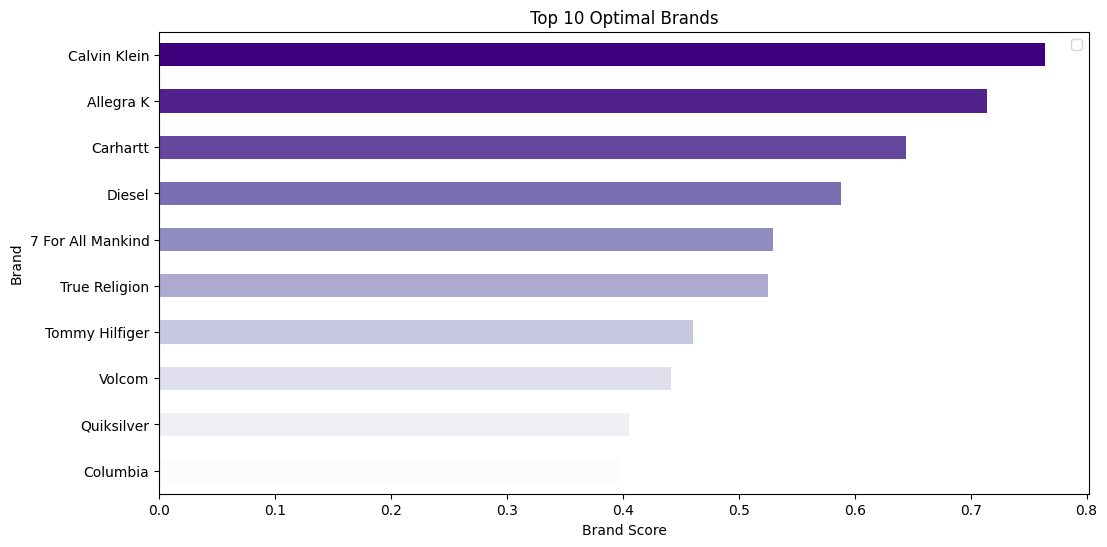

In [28]:
norm = np.linspace(0, 1, len(top10_optimal_brand))
colors = plt.cm.Purples(norm)

top10_optimal_brand.iloc[::-1].plot(
    kind='barh',
    x='product_brand',
    y='brand_score',
    color=colors,
    figsize=(12,6)
)

plt.title('Top 10 Optimal Brands')
plt.xlabel('Brand Score')
plt.ylabel('Brand')
plt.legend('')
plt.show()

Calvin Klein is the strongest performer overall, leading the ranking. Allegra K scores highly thanks to strong sales volume, even though its revenue is lower. Carhartt, Diesel, 7 For All Mankind, and True Religion occupy the middle positions, showing balanced performance. Tommy Hilfiger, Volcom, Quiksilver, and Columbia are still in the top 10 but with lower scores, indicating less optimal balance.

This chart highlights which brands are most optimal when considering both popularity and profitability together. Calvin Klein emerges as the most well‑rounded leader, while Allegra K demonstrates strength in sales but weaker revenue. The mid‑tier brands show balanced contributions, and the lower‑tier brands need improvement to achieve stronger overall performance.

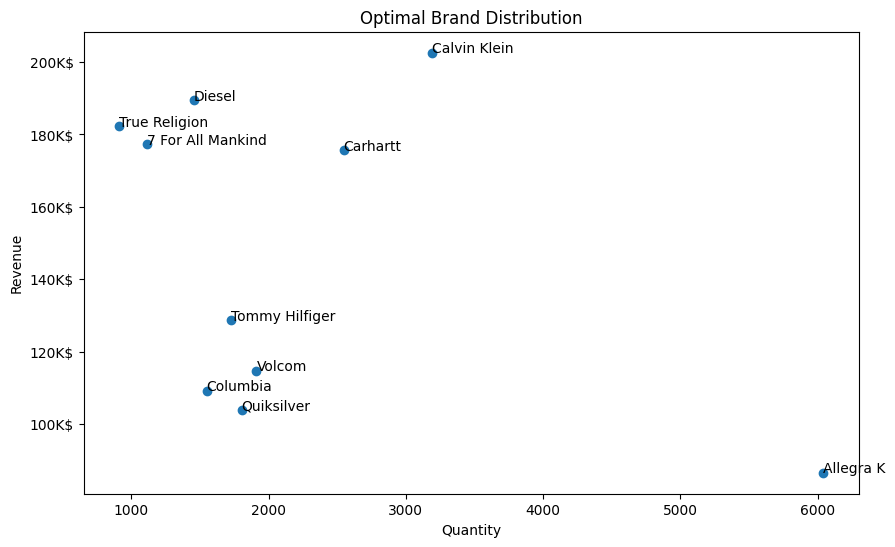

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    top10_optimal_brand['quantity'],
    top10_optimal_brand['revenue']
)

for i in range(len(top10_optimal_brand)):
    plt.text(
        top10_optimal_brand['quantity'].iloc[i],
        top10_optimal_brand['revenue'].iloc[i],
        top10_optimal_brand['product_brand'].iloc[i]
    )

plt.title('Optimal Brand Distribution')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{int(y/1000)}K$'))
plt.show()

The scatter plot adds analytical depth. It reveals the trade‑offs between quantity and revenue:

Calvin Klein dominates revenue with moderate sales.

Allegra K leads in quantity but lags in revenue.

Other brands cluster in the middle, showing more balanced performance.

## Question 4: How product category affects the revenue?

- Which product categories have the highest sales volume and revenue, and what is their revenue share?

- What are the monthly trends — are there any categories showing rapid growth?

- Which product categories are frequently purchased together (cross‑selling opportunities)?

In [30]:
df_cleaned_4a = df_cleaned.groupby('product_category').agg(
    quantity = ('product_category', 'count'),
    revenue = ('sale_price', 'sum')
).reset_index()
df_cleaned_4a


,product_category,quantity,revenue
0,Accessories,9817,4.159112e+05
1,Active,9136,4.459103e+05
2,Blazers & Jackets,3125,2.890601e+05
3,Clothing Sets,220,1.882255e+04
4,Dresses,5365,4.575536e+05
5,Fashion Hoodies & Sweatshirts,11853,6.513962e+05
6,Intimates,13432,4.515814e+05
7,Jeans,12719,1.249123e+06
8,Jumpsuits & Rompers,885,4.076613e+04
9,Leggings,3174,8.517305e+04


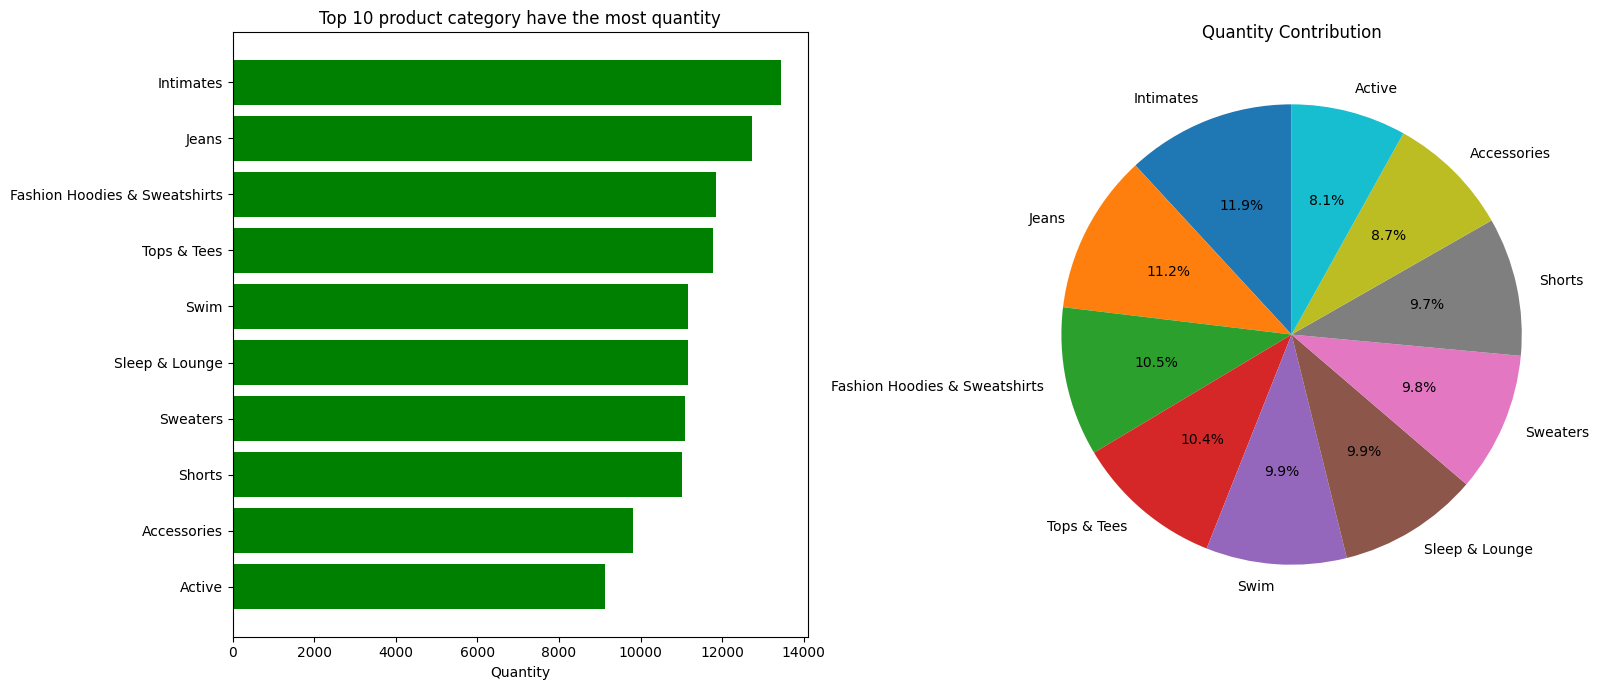

In [31]:
df_cleaned_4b = df_cleaned_4a.copy()
df_cleaned_4b1 = df_cleaned_4b.sort_values(by = 'quantity', ascending  = False).head(10)

fig, ax = plt.subplots(1,2, figsize=(16,7))

ax[0].barh(
    df_cleaned_4b1['product_category'],
    df_cleaned_4b1['quantity'],
    color = 'green'
)

ax[0].set_title('Top 10 product category have the most quantity')
ax[0].set_xlabel('Quantity')
ax[0].invert_yaxis()

ax[1].pie(
    df_cleaned_4b1['quantity'],
    labels = df_cleaned_4b1['product_category'],
    autopct='%1.1f%%',
    startangle = 90
)

ax[1].set_title('Quantity Contribution')

plt.tight_layout()
plt.show()

Intimates is the leading category with the highest quantity. Jeans, Fashion Hoodies & Sweatshirts, and Tops & Tees follow closely, showing strong demand. Categories like Active and Accessories are at the bottom of the top 10 list, but still contribute meaningfully. The gap between the top and bottom categories is not extreme, suggesting a relatively balanced distribution among the top 10. No single category dominates the overall contribution. 

The product portfolio is diverse and balanced, with no category overwhelmingly dominating. The leading categories (Intimates, Jeans, Hoodies, Tops & Tees) act as the core drivers of quantity and should be maintained as strategic pillars. Overall, the company benefits from a well-distributed product mix, reducing dependency on a single category and ensuring stability across the portfolio.

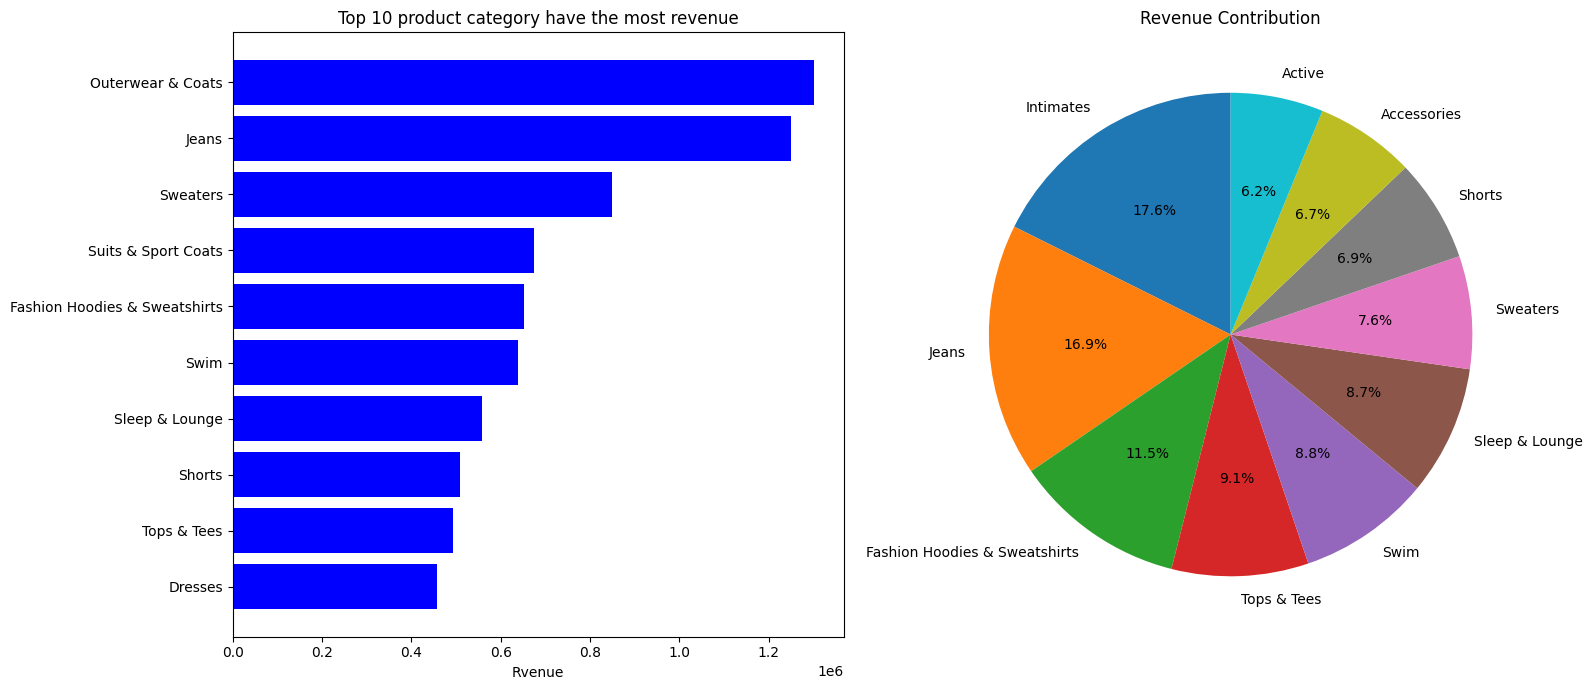

In [32]:
df_cleaned_4b2 = df_cleaned_4b.sort_values(by = 'revenue', ascending = False).head(10)

fig, ax = plt.subplots(1,2, figsize=(16,7))

ax[0].barh(
    df_cleaned_4b2['product_category'],
    df_cleaned_4b2['revenue'],
    color = 'blue'
)

ax[0].set_title('Top 10 product category have the most revenue')
ax[0].set_xlabel('Rvenue')
ax[0].invert_yaxis()

ax[1].pie(
    df_cleaned_4b2['revenue'],
    labels = df_cleaned_4b1['product_category'],
    autopct='%1.1f%%',
    startangle = 90
)

ax[1].set_title('Revenue Contribution')

plt.tight_layout()
plt.show()


Outerwear & Coats generates the highest revenue, standing out as the top-performing category. Jeans and Sweaters follow closely, showing strong sales contributions. Categories like Suits & Sport Coats and Fashion Hoodies & Sweatshirts also perform well, but at a slightly lower level.

Revenue drivers differ from quantity drivers: While Intimates were leading in quantity, they also dominate revenue contribution, highlighting their profitability. Outerwear & Coats is the single strongest category in absolute revenue, but its share in the pie chart is not the largest, meaning it generates high revenue per unit but doesn’t dominate overall sales volume.

In [33]:
# We continue dive into the trend of consuming categories of product through months

top10_category_by_revnenue = df_cleaned_4b2['product_category']
top10_category_by_revnenue


11                Outerwear & Coats
7                             Jeans
22                         Sweaters
21              Suits & Sport Coats
5     Fashion Hoodies & Sweatshirts
23                             Swim
17                   Sleep & Lounge
15                           Shorts
24                      Tops & Tees
4                           Dresses
Name: product_category, dtype: str

In [34]:
top10_category_by_revnenue = df_cleaned_4b2['product_category']
df_cleaned_4c = df_cleaned[df_cleaned['product_category'].isin(top10_category_by_revnenue)].groupby(['sale_month', 'product_category']).agg(revenue =('sale_price','sum')).reset_index()
df_cleaned_4c

,sale_month,product_category,revenue
0,1,Dresses,38725.030088
1,1,Fashion Hoodies & Sweatshirts,51174.439992
2,1,Jeans,104282.060175
3,1,Outerwear & Coats,117618.779909
4,1,Shorts,41731.190104
...,...,...,...
115,12,Sleep & Lounge,41132.100107
116,12,Suits & Sport Coats,57559.260050
117,12,Sweaters,62429.679941
118,12,Swim,47649.950003


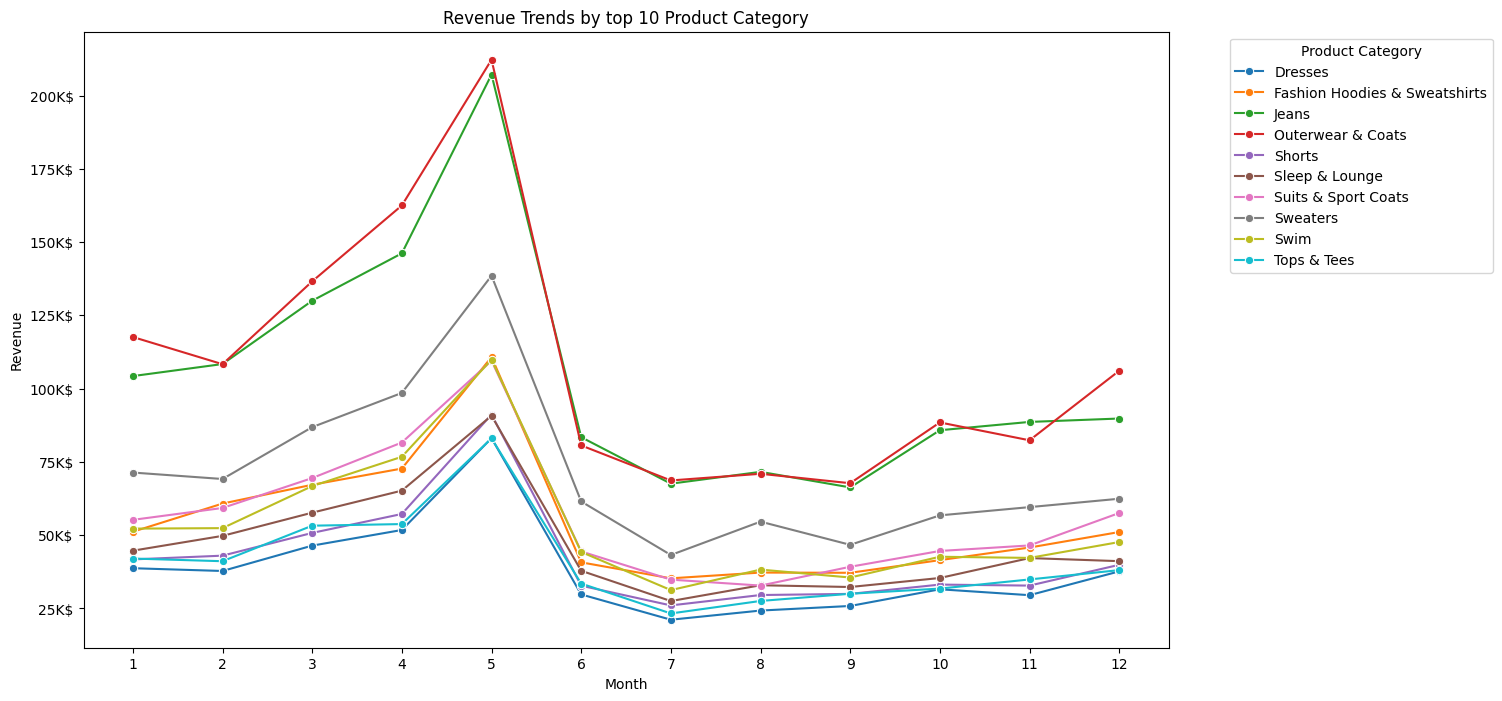

In [36]:
plt.figure(figsize=(14,8))

sns.lineplot(
    data=df_cleaned_4c,
    x='sale_month',
    y='revenue',
    hue='product_category',  
    marker='o'
)

plt.title('Revenue Trends by top 10 Product Category')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1,13))
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{int(y/1000)}K$'))
plt.show()


Outerwear & Coats and Jeans show the most significant spikes around month 5, with revenue exceeding 200,000. Other categories such as Sweaters, Fashion Hoodies & Sweatshirts, and Dresses also rise during this period, but at lower levels. All categories experience a noticeable drop immediately after the peak, suggesting a seasonal effect (possibly spring/summer transition). No category regains the high levels seen in month 5, indicating that the peak season is concentrated in the first half of the year. 

The data highlights a strong seasonal demand pattern, with month 5 being the critical revenue period across categories. Outerwear & Coats and Jeans are the key revenue drivers, both during the peak and in the stable months. For categories with lower but steady performance (Shorts, Sleep & Lounge, Swim), targeted promotions during off-peak months could help smooth revenue fluctuations. Overall, the portfolio shows clear seasonality, and aligning production, supply chain, and marketing with these cycles will be essential for sustaining growth.

## Question 5: Which customer segments are high-value? Do customers tend to buy repeatedly from the same brand or switch often?

This framework helps businesses identify customer segments by spending behavior, so they can tailor marketing strategies and product offerings accordingly.

- 0.2–50 USD: Typically small, everyday products that are easy to purchase or try out. This group represents low-value customers.

- 50–200 USD: Reflects medium spenders, often customers who buy multiple items or mid-range products.

- 200–999 USD: Indicates high-value customers, usually purchasing premium goods or buying in large quantities.

In [37]:
df_cleaned['sale_price'].sort_values(ascending = False)

79088     999.00
117361    999.00
27719     999.00
94157     999.00
94470     999.00
           ...  
14019       0.02
97044       0.02
129645      0.02
40628       0.02
57699       0.02
Name: sale_price, Length: 180508, dtype: float64

In [38]:
df_cleaned_5a = df_cleaned[['user_id', 'order_id', 'sale_price']]
df_cleaned_5a

,user_id,order_id,sale_price
0,1.0,1.0,55.000000
1,1.0,1.0,68.949997
2,1.0,1.0,11.990000
3,1.0,1.0,49.990002
4,1.0,2.0,42.000000
...,...,...,...
180503,99997.0,124508.0,8.990000
180504,99998.0,124509.0,44.000000
180505,99999.0,124510.0,75.000000
180506,100000.0,124511.0,69.989998


In [40]:
# Calculate the total order value for each order_id
order_totals = df_cleaned_5a.groupby(['user_id', 'order_id'])['sale_price'].sum()

# Then calculate the average order value for each user_id
mean_values = order_totals.groupby('user_id').mean()

# Convert the result into a DataFrame if needed
df_cleaned_5b = mean_values.reset_index()
df_cleaned_5b.columns = ['user_id', 'mean_value']



In [41]:
df_cleaned_5b['segment'] = np.where(df_cleaned_5b['mean_value'] < 100, 'low segment',
                           np.where(df_cleaned_5b['mean_value'] < 400, 'medium segment',
                                    'high segment'))
df_cleaned_5b

,user_id,mean_value,segment
0,1.0,88.240000,low segment
1,3.0,16.495000,low segment
2,4.0,141.789997,medium segment
3,5.0,212.439999,medium segment
4,6.0,64.900002,low segment
...,...,...,...
79981,99996.0,44.990000,low segment
79982,99997.0,35.040000,low segment
79983,99998.0,44.000000,low segment
79984,99999.0,75.000000,low segment


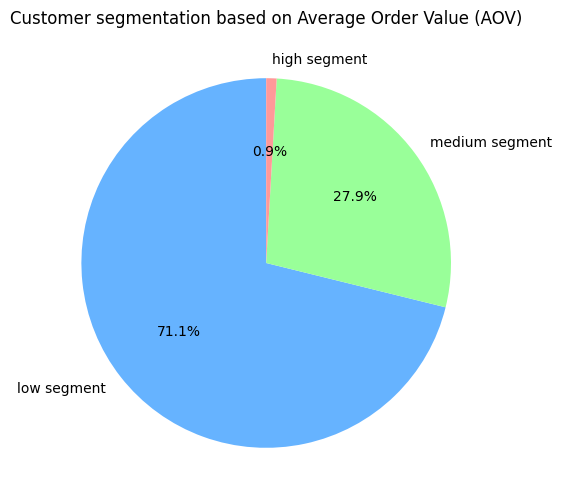

In [42]:
# Count the number of customers of each segment
segment_counts = df_cleaned_5b['segment'].value_counts()

# Create a pie chart
plt.figure(figsize=(6,6))
plt.pie(segment_counts, 
        labels=segment_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Customer segmentation based on Average Order Value (AOV)')
plt.show()


The business is heavily reliant on low-value customers, which means high transaction volume but lower margins per order.

The medium segment is promising: although smaller, it contributes more revenue per order and could be nurtured through loyalty programs or bundled offers.

The high-value segment, while small, is strategically important. These customers are likely the most profitable and should be targeted with personalized services, exclusive deals, or VIP programs.

Overall, the segmentation suggests a need to balance strategies: maintain accessibility for low-value customers while actively growing the medium and high-value segments to improve profitability.